In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots

plt.style.use('science')

metrics_dir = "./augmented_datasets_metrics"
charts_dir = "./augmented_dataset_charts"


In [2]:
headers = ["model", "method", "dataset", "augmentation_rate", "tsed_score"]
all_data = []

for root, _, files in os.walk(metrics_dir):
    if "deepseek" in root:
        continue

    if "paraphrase" in root:
        continue

    for file in files:
        if not file.endswith(".csv"):
            continue

        file_path = os.path.join(root, file)
        df = pd.read_csv(file_path)

        if df.empty or "augmentation_rate" not in df.columns:
            continue

        df["augmentation_rate"] = df["augmentation_rate"].astype(float)
        df.sort_values("augmentation_rate", inplace=True)

        valid_rates = df["augmentation_rate"].value_counts()
        valid_rates = valid_rates[valid_rates == 5].index
        df = df[df["augmentation_rate"].isin(valid_rates)]

        if df.empty:
            continue

        mean_df = df.groupby("augmentation_rate")[["tsed_score"]].mean().dropna()
        for i, row in mean_df.iterrows():
            all_data.append([df["model"][0], df["method"][0], df["dataset"][0], i, row["tsed_score"]])
        break

# print(len(all_data))
# print(all_data)

In [3]:
df = pd.DataFrame(all_data, columns=headers)

In [4]:
model_names = {
    "claude": "Claude 3 Haiku",
    "openai": "GPT-4o mini",
    "gemini": "Gemini 2.0 Flash",
    "llama": "Llama 3.3 70B"
}

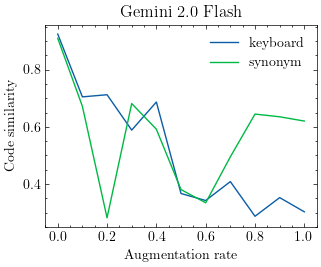

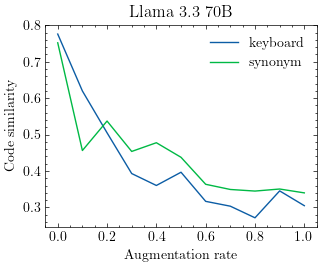

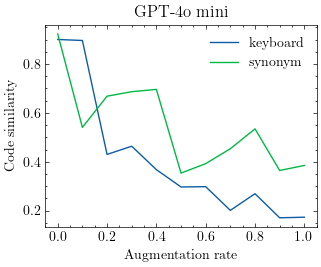

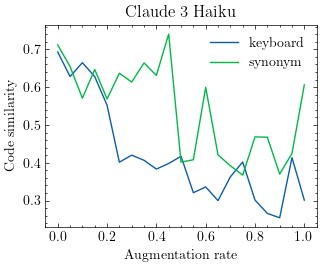

In [5]:
for model in df["model"].unique().tolist():
    fig, ax = plt.subplots()
    for method in df["method"].unique().tolist():
        mm_df = df[(df["model"] == model) & (df["method"] == method)]
        means = mm_df.groupby("augmentation_rate")[["tsed_score"]].mean()
        ax.plot(means.index, means["tsed_score"], label=method)
    ax.set_title(model_names[model])
    ax.set_xlabel("Augmentation rate")
    ax.set_ylabel("Code similarity")
    plt.legend()
    plt.show()


# for group in df.groupby(["model", "method", "augmentation_rate"]):
#     print(group[0])
#     print(group[1])
#     break